# 1. 乳腺癌分类

## 加载数据

In [1]:
from sklearn.datasets import load_breast_cancer

# ── 加载数据 ──────────────────────────────────────────────────────────
data = load_breast_cancer()
X, y = data.data, data.target

print(f'样本数：{X.shape[0]}，特征数：{X.shape[1]}')
print(f'类别：{data.target_names}  →  0={data.target_names[0]}, 1={data.target_names[1]}')
print(f'各类别数量：恶性={sum(y==0)}, 良性={sum(y==1)}')


样本数：569，特征数：30
类别：['malignant' 'benign']  →  0=malignant, 1=benign
各类别数量：恶性=212, 良性=357


- malignant 恶性的
- begnign   良性的

In [3]:
for i in range(len(data.target_names)):
  print(f"{i}: {data.target_names[i]}")

0: malignant
1: benign


## 查看特征

In [2]:
import pandas as pd
# 查看前几行特征
df = pd.DataFrame(X[:5], columns=data.feature_names)
df['label'] = y[:5]
df


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [11]:
d = pd.DataFrame(X, columns = data.feature_names)
d['label'] = y
d.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


特征值的量纲差异很大,需要标准化后再训练

## 划分数据集

划分数据集：80% 训练集 / 20% 测试集，stratify=y 保证两个子集的类别比例一致

In [3]:
# ── 划分训练集 / 测试集 ───────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 预处理特征

标准化：用训练集的均值和标准差对特征做 Z-score 归一化，同样的变换应用到测试集

In [4]:
# ── 特征标准化（逻辑回归对量纲敏感）──────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


## 训练模型

训练逻辑回归：使用交叉熵损失 + L2 正则化

In [5]:
# ── 训练逻辑回归模型 ──────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print('训练完成 ✅')
print(f'训练集准确率：{model.score(X_train_scaled, y_train):.4f}')
print(f'测试集准确率：{model.score(X_test_scaled,  y_test):.4f}')

训练完成 ✅
训练集准确率：0.9890
测试集准确率：0.9825


## 结果分析
- 训练集和测试集准确率均在 97%~98% 左右，说明模型拟合效果好且没有明显过拟合
- 训练集与测试集准确率相差不大，模型具备良好的泛化能力
- 逻辑回归作为线性模型，在该数据集上表现出色，说明乳腺癌特征与标签之间存在较强的线性可分性

## 可视化概率分布

In [6]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
# plt.rcParams['font.family'] = 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False

In [22]:
model.predict_proba(X_test_scaled)

array([[9.99999941e-01, 5.88824186e-08],
       [1.13351672e-05, 9.99988665e-01],
       [9.93589175e-01, 6.41082462e-03],
       [4.66491463e-01, 5.33508537e-01],
       [9.99999999e-01, 6.52500097e-10],
       [7.83960163e-03, 9.92160398e-01],
       [1.71746799e-05, 9.99982825e-01],
       [9.99999436e-01, 5.63527494e-07],
       [9.99945684e-01, 5.43163692e-05],
       [1.00000000e+00, 8.04184941e-11],
       [1.08214445e-02, 9.89178556e-01],
       [9.98667581e-01, 1.33241870e-03],
       [1.29622345e-03, 9.98703777e-01],
       [9.99973941e-01, 2.60592467e-05],
       [9.99723775e-01, 2.76224627e-04],
       [9.83676461e-02, 9.01632354e-01],
       [6.34138144e-01, 3.65861856e-01],
       [1.65002350e-01, 8.34997650e-01],
       [3.38813138e-05, 9.99966119e-01],
       [1.69826652e-02, 9.83017335e-01],
       [9.98342281e-01, 1.65771925e-03],
       [9.48260020e-01, 5.17399797e-02],
       [1.92114587e-04, 9.99807885e-01],
       [8.76676314e-04, 9.99123324e-01],
       [9.989782

`model.predict_proba(INPUT)`
- 根据 `model` 对 `INPUT` 的样本预测对应各标签的概率
- 输出二维 `array` 数组
  - 每行对应每个样本
  - 每列对应每个标签的概率，概率按索引顺序对应标签

In [21]:
model.predict(X_test_scaled)

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

model.predict(INPUT)
- 根据 `model` 对 `INPUT` 的样本预测标签
- 输出一维 `array` 数组
  - 每个值为预测的每个样本的标签

### 获取测试集的预测结果

In [7]:
# ── 获取测试集预测概率 ────────────────────────────────────────────────
proba = model.predict_proba(X_test_scaled)[:, 1]   # 良性（1）的概率
preds = model.predict(X_test_scaled)


### 按真实标签分组

- `[y_test == 0]` 得到 真实标签为恶性(0) 的样本索引
- `[y_test == 1]` 得到 真实标签为良性(1) 的样本索引

In [8]:
# ── 按真实标签分组 ────────────────────────────────────────────────────
proba_malignant = proba[y_test == 0]   # 真实恶性样本的预测概率
proba_benign    = proba[y_test == 1]   # 真实良性样本的预测概率


### 绘图

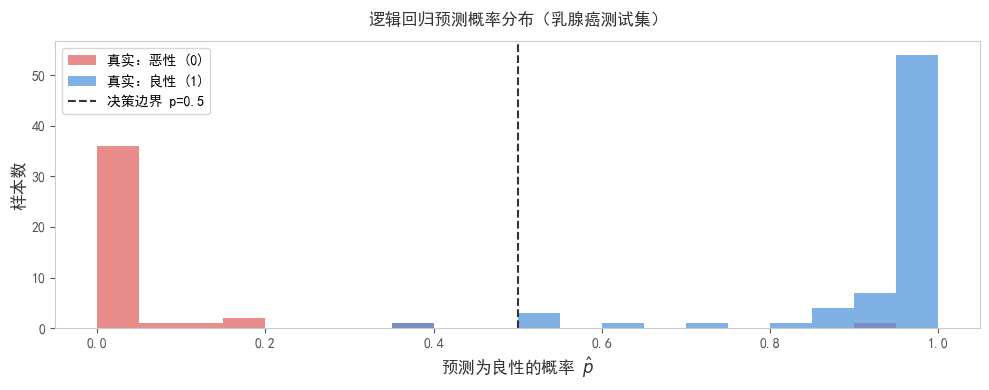


📌  红色分布集中在 0 附近（模型认为这些是恶性），蓝色分布集中在 1 附近（模型认为是良性）
    两组分布分离越明显，说明模型区分能力越强。


In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.hist(proba_malignant, bins=20, color='#e05c5c', alpha=0.7, label='真实：恶性 (0)', range=(0, 1))
ax.hist(proba_benign,    bins=20, color='#4a90d9', alpha=0.7, label='真实：良性 (1)', range=(0, 1))
ax.axvline(0.5, color='#333333', linewidth=1.5, linestyle='--', label='决策边界 p=0.5')

ax.set_xlabel(r'预测为良性的概率 $\hat{p}$', color='#333333', fontsize=12)
ax.set_ylabel('样本数', color='#333333', fontsize=12)
ax.set_title('逻辑回归预测概率分布（乳腺癌测试集）', color='#333333', fontsize=12, pad=12)
ax.tick_params(colors='#555555')
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')
ax.legend(fontsize=10, facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.show()

print('\n📌  红色分布集中在 0 附近（模型认为这些是恶性），蓝色分布集中在 1 附近（模型认为是良性）')
print('    两组分布分离越明显，说明模型区分能力越强。')

# 2. 评估指标

## 混淆矩阵

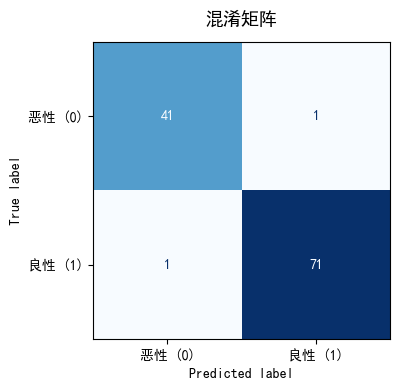

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# plt.rcParams['font.family'] = 'Arial Unicode MS'
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

y_pred = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
fig.patch.set_facecolor('white')
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['恶性 (0)', '良性 (1)']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('混淆矩阵', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()

**结果分析**
- 对角线上的数字越大越好，代表预测正确的样本数
- **FN（漏报恶性）** 在医疗场景中危害最大——真实是恶性却被预测为良性，患者可能因此延误治疗
- **FP（误报恶性）** 的代价相对较低，只是增加不必要的复查
- 混淆矩阵直观展示了模型在每个类别上的具体表现，是准确率之外最重要的参考

## 精确率/召回率/F1

In [15]:
from sklearn.metrics import classification_report, accuracy_score

print('准确率（Accuracy）:', accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=['恶性 (0)', '良性 (1)']))

准确率（Accuracy）: 0.9824561403508771

              precision    recall  f1-score   support

      恶性 (0)       0.98      0.98      0.98        42
      良性 (1)       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



结果分析
- macro avg：对每个类别单独计算后取平均，不考虑类别样本数量差异
- weighted avg：按各类别样本量加权平均，更能反映整体表现
- 在乳腺癌这类场景中，恶性（0）的召回率是最重要的指标——宁可误报，不能漏报
- 若召回率不足，可以通过调低决策阈值（默认 0.5）来提升，以牺牲部分精确率为代

## ROC/AUC

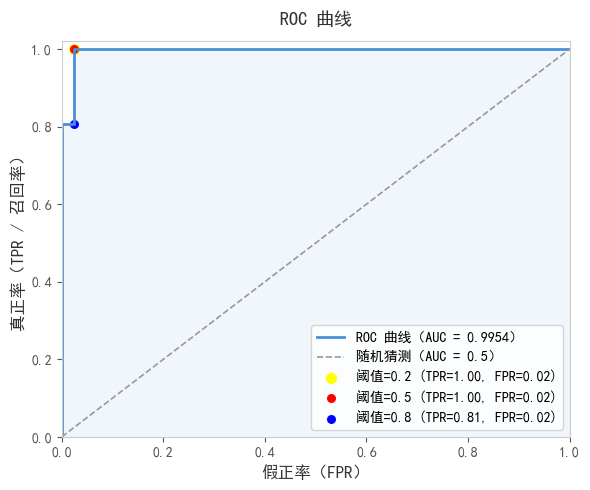

AUC = 0.9954


In [16]:
from sklearn.metrics import roc_curve, auc

proba = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(fpr, tpr, color='#4a90d9', lw=2, label=f'ROC 曲线（AUC = {roc_auc:.4f}）')
ax.fill_between(fpr, tpr, alpha=0.08, color='#4a90d9')
ax.plot([0, 1], [0, 1], color='#999999', lw=1.2, linestyle='--', label='随机猜测（AUC = 0.5）')

idx = (np.abs(thresholds - 0.2)).argmin()  # 找到最接近0.2的阈值索引
plt.scatter(fpr[idx], tpr[idx], c='yellow', s=50, label=f'阈值=0.2 (TPR={tpr[idx]:.2f}, FPR={fpr[idx]:.2f})')

idx = (np.abs(thresholds - 0.5)).argmin()  # 找到最接近0.5的阈值索引
plt.scatter(fpr[idx], tpr[idx], c='red', s=30, label=f'阈值=0.5 (TPR={tpr[idx]:.2f}, FPR={fpr[idx]:.2f})')

idx = (np.abs(thresholds - 0.8)).argmin()  # 找到最接近0.8的阈值索引
plt.scatter(fpr[idx], tpr[idx], c='blue', s=30, label=f'阈值=0.8 (TPR={tpr[idx]:.2f}, FPR={fpr[idx]:.2f})')

ax.set_xlabel('假正率（FPR）', color='#333333', fontsize=12)
ax.set_ylabel('真正率（TPR / 召回率）', color='#333333', fontsize=12)
ax.set_title('ROC 曲线', color='#333333', fontsize=13, pad=12)
ax.tick_params(colors='#555555')
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')
ax.legend(fontsize=10, facecolor='white', edgecolor='#cccccc')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

print(f'AUC = {roc_auc:.4f}')

结果分析
- AUC 接近 1.0，ROC 曲线紧贴左上角，说明模型在任意阈值下都能较好地区分恶性和良性
- 曲线越靠近左上角（高 TPR + 低 FPR），模型性能越好；对角虚线代表随机猜测的基准线
- AUC 与具体阈值无关，是比单一准确率更稳健的综合评价指标，适合用于模型之间的横向对比